In [1]:
import pickle
import matplotlib.pyplot as plt

In [2]:
filepath = '/global/homes/r/rory_m/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/background_templates/'
folder = '2D_neutrons/'
filename = '2D_neutrons_0.1'



with open('/global/cfs/cdirs/lz/users/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/background_templates/3D_neutrons_may/80t/0.1.pkl', 'rb') as file:
    data = pickle.load(file)


print(data)

[{'SolarER': <multihist.Histdd object at 0x7fcbd3e9d990>, 'Pb214': <multihist.Histdd object at 0x7fcb250ae310>, 'Kr85': <multihist.Histdd object at 0x7fcb250ae450>, 'Xe136': <multihist.Histdd object at 0x7fcb250ae610>, 'Xe124': <multihist.Histdd object at 0x7fcb250ae7d0>, 'CEvNS_solar': <multihist.Histdd object at 0x7fcb250ae990>, 'CEvNS_other_LNGS': <multihist.Histdd object at 0x7fcb250aeb10>, 'CEvNS_other_SURF': <multihist.Histdd object at 0x7fcb250aec90>, 'neutrons_LNGS': <multihist.Histdd object at 0x7fcb250aee50>}, {'WIMP': <multihist.Histdd object at 0x7fcb250af050>}]


In [15]:
print(data[0])
print(data[1])

print(data[0]['neutrons_LNGS'])

{'SolarER': <multihist.Histdd object at 0x7fcbd3e9d990>, 'Pb214': <multihist.Histdd object at 0x7fcb250ae310>, 'Kr85': <multihist.Histdd object at 0x7fcb250ae450>, 'Xe136': <multihist.Histdd object at 0x7fcb250ae610>, 'Xe124': <multihist.Histdd object at 0x7fcb250ae7d0>, 'CEvNS_solar': <multihist.Histdd object at 0x7fcb250ae990>, 'CEvNS_other_LNGS': <multihist.Histdd object at 0x7fcb250aeb10>, 'CEvNS_other_SURF': <multihist.Histdd object at 0x7fcb250aec90>, 'neutrons_LNGS': <multihist.Histdd object at 0x7fcb250aee50>}
{'WIMP': <multihist.Histdd object at 0x7fcb250af050>}


In [35]:
template_s1s2 = data[0]['neutrons_LNGS']

In [36]:
template_norm = template_s1s2.n
template_s1s2 = template_s1s2 / template_s1s2.n
template_s1s2 = template_s1s2 / template_s1s2.bin_volumes()

In [37]:
template_norm

0.0045874229309570795

In [40]:
template_s1s2

In [31]:
hist = data[0]['neutrons_LNGS']

In [32]:
print(hist.__dict__.keys())

dict_keys(['axis_names', 'histogram', 'bin_edges'])


In [33]:
print(hist.axis_names)
print(hist.histogram.shape)
print([len(e) for e in hist.bin_edges])

['cS1', 'log10_cS2', 'rsq']
(100, 100, 50)
[101, 101, 51]


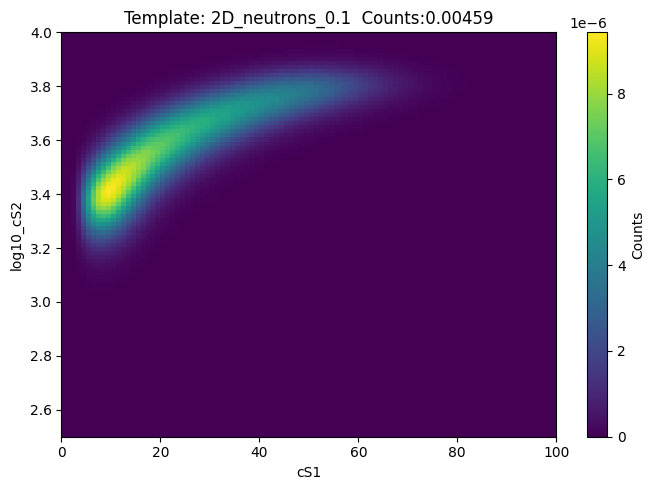

In [34]:
import numpy as np
arr = hist.histogram

if arr.ndim == 2:
    x_edges = hist.bin_edges[0]
    y_edges = hist.bin_edges[1]
    X, Y = np.meshgrid(x_edges, y_edges)
    plt.figure(figsize=(7,5))
    pcm = plt.pcolormesh(X, Y, arr.T, cmap='viridis')
    plt.colorbar(pcm, label='Counts')
    plt.xlabel(hist.axis_names[0] if hasattr(hist, 'axis_names') else 'x')
    plt.ylabel(hist.axis_names[1] if hasattr(hist, 'axis_names') else 'y')
    plt.title(f"Template: {filename}  Counts:{hist.n :.5f}")
    plt.tight_layout()
    plt.show()

elif arr.ndim == 1:
    # keep existing 1D behaviour
    hist.plot()
    plt.title(f"Template: {filename}  Counts:{hist.n :.5f}")
    plt.show()

else:
    # project all axes beyond the first two
    proj = arr.sum(axis=tuple(range(2, arr.ndim))) if arr.ndim > 2 else arr
    if len(hist.bin_edges) >= 2:
        x_edges = hist.bin_edges[0]
        y_edges = hist.bin_edges[1]
        X, Y = np.meshgrid(x_edges, y_edges)
        plt.figure(figsize=(7,5))
        pcm = plt.pcolormesh(X, Y, proj.T, cmap='viridis')
        plt.colorbar(pcm, label='Counts')
        plt.xlabel(hist.axis_names[0] if hasattr(hist, 'axis_names') else 'x')
        plt.ylabel(hist.axis_names[1] if hasattr(hist, 'axis_names') else 'y')
        plt.title(f"Template: {filename}  Counts:{hist.n :.5f}")
        plt.tight_layout()
        plt.show()
    else:
        hist.plot()
        plt.title(f"Template: {filename}  Counts:{hist.n :.5f}")
        plt.show()